# Welcome to spectral fitting with COSIpy classic

In this notebook, we'll perform a spectral fit of the Crab nebula using the 2016 balloon flight data.

## Import packages.

We're using the COSIpy classic functions in COSIpy_dc1.py, response_dc1.py, and fit_dc1.py.

In [1]:
from pathlib import Path
import sys

repo_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'src' / 'cosipy_classic').is_dir())
sys.path.insert(0, str(repo_root / 'src'))

from cosipy_classic.COSIpy_dc1 import *
from cosipy_classic import response_dc1 as response
from cosipy_classic.fit_dc1 import *

Display not found: DISPLAY environment variable is unset or empty
Switching to batch mode



## Define file names.

In [8]:
data_dir = str(repo_root / 'data' / 'flight') # directory containing flight event files
filename_data = 'Crab_COSIBalloonData.tra.gz' # 2016 balloon data
response_filename = str(repo_root / 'data' / 'responses' / 'Continuum_imaging_response.npz') # detector response
background_filename = str(repo_root / 'data' / 'backgrounds' / 'Scaled_Ling_BG_1x.npz') # background response
background_mode = 'from file'

## Define inputs.

In [9]:
l_crab,b_crab = 184.55746, -5.78436 # Galactic longitude & latitude of Crab

ul = 3 # SNR limit for upper limits on spectral fit

## Read in data and define analysis object.

Read in the data set and create the main cosipy-classic “analysis_data" object, which provides various functionalities to study the specified file. This cell usually takes a few minutes to run.

In [10]:
analysis_data = COSIpy(data_dir,filename_data) # create analysis object
analysis_data.read_COSI_DataSet() # read in data

# Bin the data
The data are binned into time, energy, ϕ and FISBEL. FISBEL is a unique index which specifies the χ and ψ dimensions of the CDS.

Calling "get_binned_data()" may take several minutes, depending on the size of the dataset and the number of bins. Keep an eye on memory here: if your time bins are very small, for example, this could be an expensive operation.

In [27]:
#Define the bin sizes
Delta_T = 1800 # time bin size in seconds
energy_bin_edges = np.array([150,  220,  325,  480,  520,  765, 1120, 1650, 2350, 3450, 5000]) # energy bin edges in keV
pixel_size = 6. # pixel size in degrees

analysis_data.dataset.time_binning_tags(time_bin_size=Delta_T) # time binning
analysis_data.dataset.init_binning(energy_bin_edges=energy_bin_edges,pixel_size=pixel_size) # energy and pixel binning
analysis_data.dataset.get_binned_data() # bin data

## Examine the shape of the binned data.

The binned data are contained in "analysis_combined.dataset.binned_data". This is a 4-dimensional object representing the 5 dimensions of the Compton data space (time, energy, ϕ, FISBEL).

This prints the shape of the binned data, the total time in the dataset, the number of time bins that have counts in them, and the number of counts in each time bin. Due to this energy range being so background dominated, the number of counts in each bin is very similar.

In [28]:
print('Number of bins in each dimension (time, energy, ϕ, FISBEL):')
print(analysis_data.dataset.binned_data.shape)
print()
print('Total time in dataset (s):')
print(analysis_data.dataset.times.total_time)
print()
print('Number of populated time bins:')
print(analysis_data.dataset.times.n_ph)
print()
print('Number of counts in each time bin: ')
print(analysis_data.dataset.times.n_ph_t)

Number of bins in each dimension (time, energy, ϕ, FISBEL):
(308, 10, 30, 1145)

Total time in dataset (s):
553596.7616381645

Number of populated time bins:
308

Number of counts in each time bin: 
[ 860    0    0 ... 1635 1632  873]


## Plot  raw spectrum & light curve.

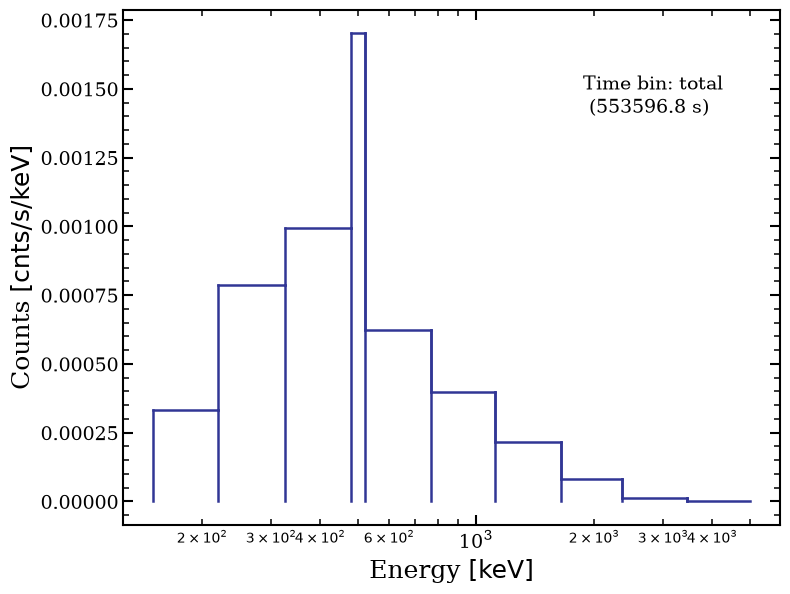

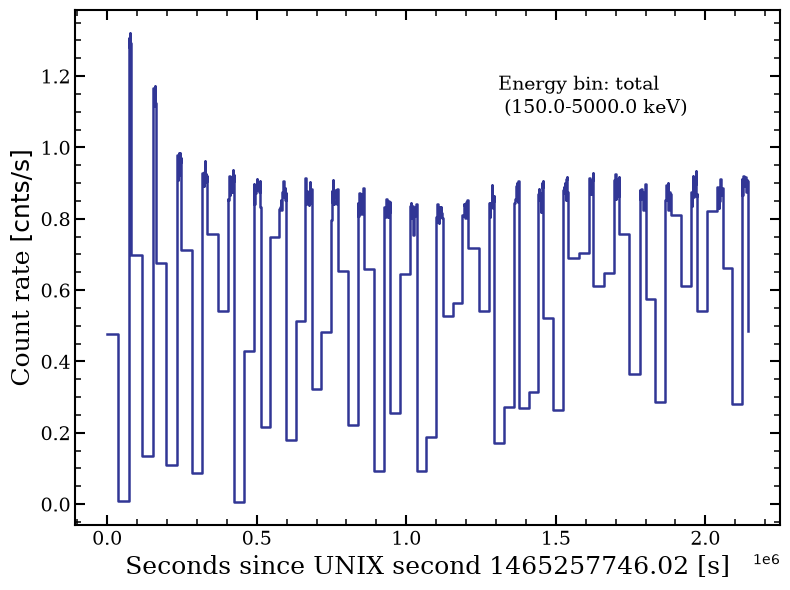

In [29]:
analysis_data.dataset.plot_raw_spectrum()
plt.xscale('log')

analysis_data.dataset.plot_lightcurve()

## Define the pointing object with the COSIpy pointing class.

The pointings refer to the direction/orientation of the telescope at each point in time. This cell usually takes a few minutes to run.

In [30]:
pointing_data = Pointing(dataset=analysis_data.dataset) # definition of pointings (balloon stability + Earth rotation)

## Visualize the paths of the Crab through the field-of-view.

This isn't necessary for the spectral fitting, but is illustrative for understanding the pointings and exposure of the point source.

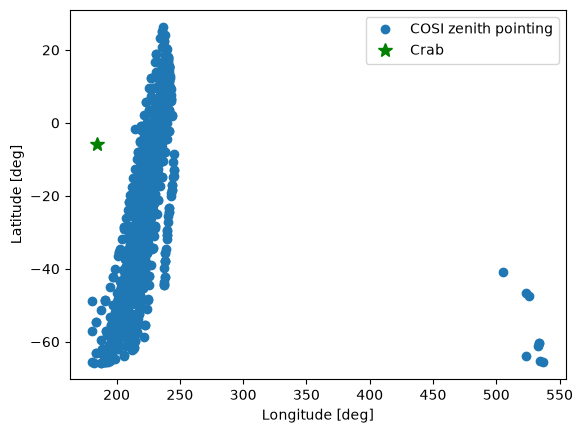

In [31]:
plt.plot(pointing_data.zpoins[:,0]+360,pointing_data.zpoins[:,1],'o', label="COSI zenith pointing")
plt.plot(l_crab,b_crab,'*g',markersize=10, label="Crab")
plt.xlabel('Longitude [deg]')
plt.ylabel('Latitude [deg]')
plt.legend()

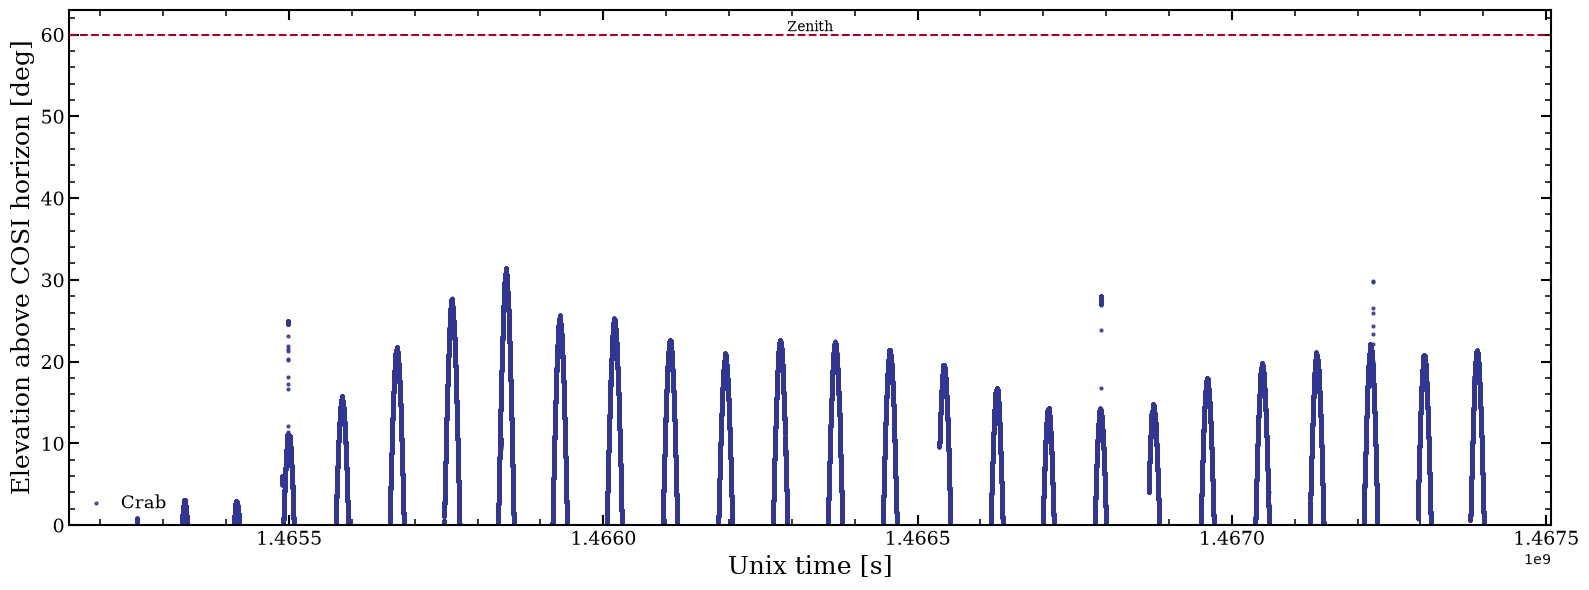

In [32]:
analysis_data.plot_elevation([l_crab],[b_crab],['Crab'])

# Define a tracer.
Since background of the balloon data varies with time, here we define a "tracer" for our background model. 
The tracer normalizes the background model to the data in each time bin. 

In [33]:
# Define tracer
tracer = np.sum(analysis_data.dataset.binned_data,axis=(1,2,3))
tracer = tracer/np.mean(tracer)

# Define the BG model.

In [34]:
# Ling BG simulation to model atmospheric background
background_data = BG(dataset=analysis_data.dataset,mode=background_mode,filename=background_filename,tracer=tracer) # read in background

Using background mode: from file


# Read in the Response Matrix

This usually takes a few minutes.

In [35]:
# continuum response
rsp = response.SkyResponse(filename=response_filename,pixel_size=pixel_size) # read in detector response

Reading response.
Done.

Creating general RMF matrices.


Loop over phi bins::   0%|          | 0/30 [00:00<?, ?it/s]

Done.

Creating general IRF.
Done.

Deleting full matrix.
Done.


## Explore the shape of the data space.

The shape of the response spans (Galactic latitude $b$, Galactic longitude $\ell$, Compton scattering angle $\phi$, FISBEL, energy). The shape of the data and background objects span (time, energy, Compton scattering angle, FISBEL), as explained above.

In [36]:
print('Shape of response matrix (b, l, ϕ, FISBEL, energy):')
print(rsp.rsp.response_grid_normed_efinal.shape)
print()
print('Shape of binned data (time, energy, ϕ, FISBEL):')
print(analysis_data.dataset.binned_data.shape)
print()
print('Shape of background model (time, energy, ϕ, FISBEL):')
print(np.shape(background_data.bg_model))

Shape of response matrix (b, l, ϕ, FISBEL, energy):
(30, 60, 30, 1145, 10)

Shape of binned data (time, energy, ϕ, FISBEL):
(308, 10, 30, 1145)

Shape of background model (time, energy, ϕ, FISBEL):
(308, 10, 30, 1145)


# Calculate the point source response for the Crab.

In [37]:
rsp.calculate_PS_response(analysis_data.dataset,pointing_data,l_crab,b_crab,1,background=background_data,pixel_size=pixel_size,lookup=False)

Loop over energy bins:   0%|          | 0/10 [00:00<?, ?it/s]

Loop over pointings::   0%|          | 0/1991 [00:00<?, ?it/s]

## Plot light curves for the data, background & sky models.

This is plotted for the 220-325 keV energy bin. The sky model is normalized to 1.

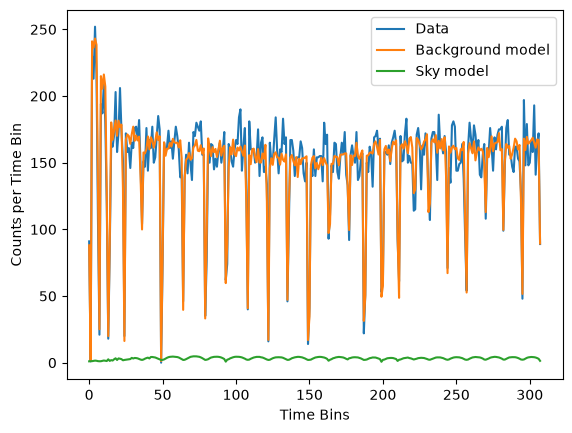

In [38]:
plt.plot(np.sum(analysis_data.dataset.binned_data[:,1,:,:],axis=(1,2)), label="Data") # binned data light curve
plt.plot(np.sum(background_data.bg_model_reduced[1],axis=1), label="Background model") # background model
plt.plot(np.sum(rsp.sky_response[1],axis=1)*1000, label="Sky model") # sky model
plt.xlabel('Time Bins')
plt.ylabel('Counts per Time Bin')
plt.legend()

# Extract the spectrum for the Crab.

For each energy bin individually, this determines the coefficients for the sky and background models that best match the data. It can take a few hours to run!

In [39]:
result_crab = fit(analysis_data.dataset,pointing_data,rsp,background_data) # create fitting object
result_crab.fit(iters=2000) # perform spectral fit using emcee (uses pointing definition, background model, & point source response)

working on energy bin 0


100%|██████████| 2000/2000 [00:13<00:00, 145.57it/s]


working on energy bin 1


100%|██████████| 2000/2000 [00:27<00:00, 71.95it/s]


working on energy bin 2


...

100%|██████████| 2000/2000 [01:16<00:00, 26.10it/s]


working on energy bin 8


100%|██████████| 2000/2000 [01:09<00:00, 28.73it/s]


working on energy bin 9


100%|██████████| 2000/2000 [00:56<00:00, 35.67it/s]


## Plot the final count spectrum of the Crab.

Below is the spectrum (in counts/keV) of the Crab nebula!

The extracted spectrum data is saved as a .dat file.

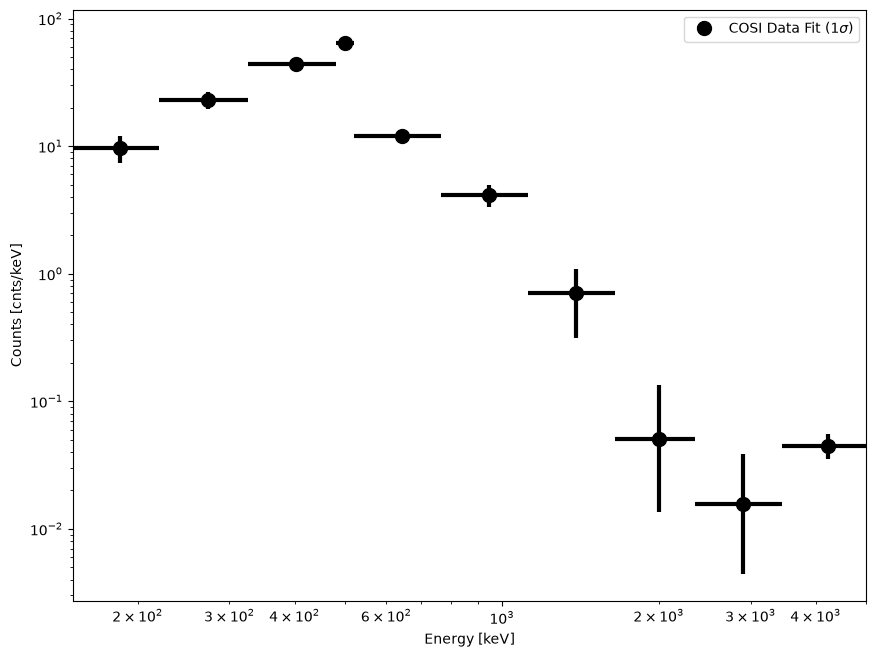

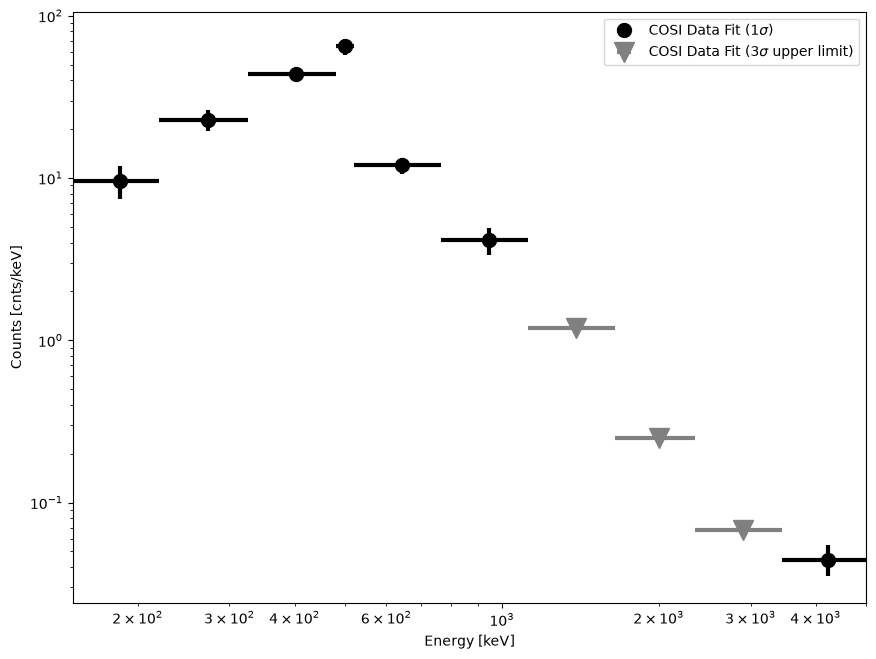

In [41]:
result_crab.plot_extracted_spectrum('crab_spectrum.dat')
result_crab.plot_extracted_spectrum('crab_spectrum.dat',ul=3)